# Notebook 2: Predict short term BTC returns based on order flow 

**Recap - Notebook 1 Findings**

In Notebook1 we investigated two intraday momentum signals for BTC: one based purely on past time series returns and the second based on instantaneous order book flow. Out of the two signals, it was shown that instantaneous order book flow plays a better role at predicting future returns. However, ultimately trading at a high frequency is not likely to be profitable due to short term returns not being large enough to account for the impact of Binance fees. 

**Reframe notebook focus - predict price movements** 

I am nonetheless interested in how we might predict short term price movements in BTC. This notebook focuses SOLELY on how we can try to predict raw returns based on order flow information. In Notebook1 we showed that instantaneous order book information has a nonzero rank correlation with future returns and that this correlation is highest when we look at a very high frequency (10s). 

In this notebook I will investigate whether it's even feasible to try and predict short term price movements in BTC based on order flow information. This analysis is inspired by an Optiver Kaggle competition of predicting the short term future median price movements of an index (i.e. the next 60 seconds): https://www.kaggle.com/competitions/optiver-trading-at-the-close. 

In [15]:
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm

%load_ext autoreload
%autoreload 2
%matplotlib inline 

import lakeapi
import datetime as dt
from datetime import timedelta, datetime, date, time
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd
import time
import plotly.graph_objects as go 
import mplfinance as mpf
from scipy.stats import pearsonr
from itertools import product

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
pd.set_option('display.max_rows', 100)

from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from tqdm import tqdm
import seaborn as sns

#my functions 
from helpers import make_features
from train import walk_forward_validate
from eda import qq_plot, plot_kde, plot_scatter_hex

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Data Sources 

The data comprises of 10 second snapshots in BTC order book (top 20 levels) from Binance exchange from around October 2025 - December 2025. I have created ~ 50 features related to order book flow such as bid ask spread, price momentum, etc. 

In [16]:
#global variables 

PARAMS = {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
}

TRAIN_TEST_SPLIT_PARAMS = {
    'num_splits': 10, 
    'split_ratio': 0.8, 
}

TARGET = 'fwd_ret_3'

QR_PARAMS = {
    'alpha': 0.0,
}
BASIS_POINTS_CONVERSION = 10_000
HOLDING_PERIODS =  [3, 6, 18, 30, 60, 120, 300]

In [ ]:
#import/load raw data 
raw_df = pd.read_parquet("data/crypto_book_10s_data.parquet")
df, FEAS_LIST = make_features(raw_df)
train_df = df.loc[:'2025-12-19'].dropna()

In [5]:
len(train_df)

690900

To reserve data for testing we limit training_df to approximately the first month of data.

# What are we trying to predict? 

In Notebook1 I showed the (fairly obvious) result that instantaneous order book imbalance best predicts short term returns (i.e. 30 seconds into the future) - predictability the signal degrades the further we go out. So I will focus on trying to predict short term returns (30 seconds into the future). 

# Initial Diagnostics/EDA 

## Target Variable(s)

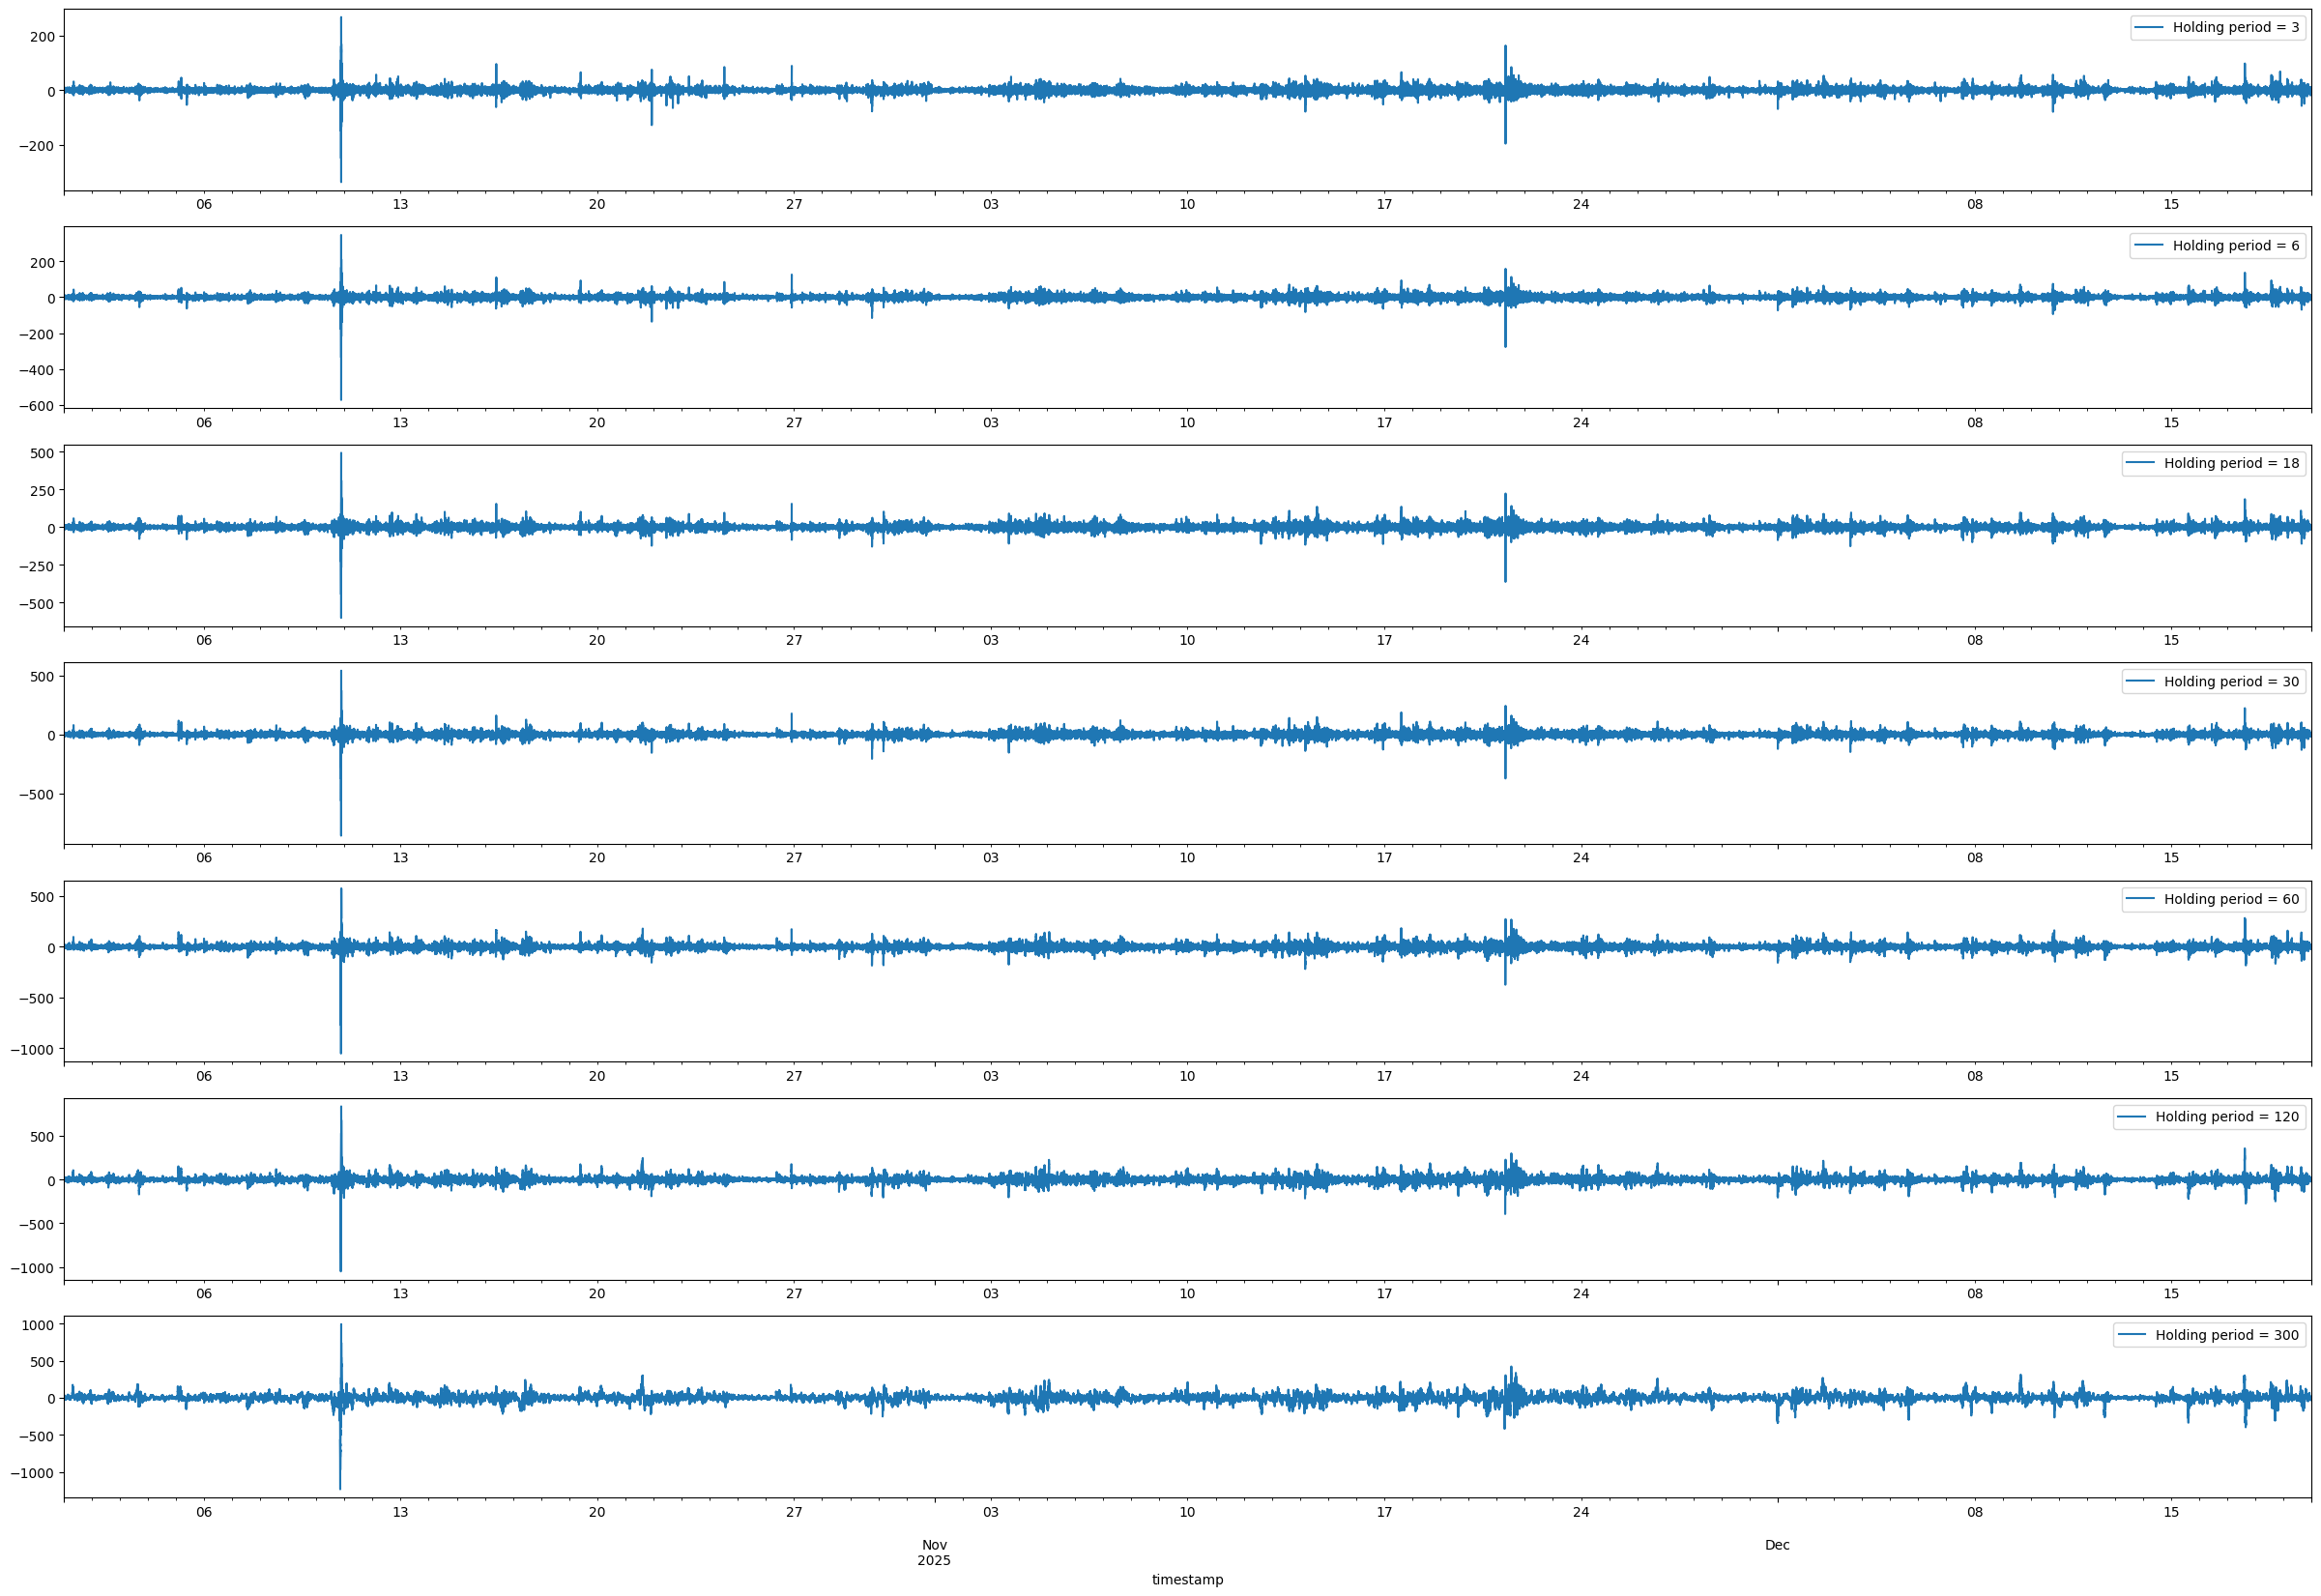

In [7]:
#Plot target variable 
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(nrows = len(HOLDING_PERIODS), figsize = (30, 20))
for h, a in zip(HOLDING_PERIODS, ax): 
    train_df[f'fwd_ret_{h}_bp'].plot(ax = a, label = f'Holding period = {h}')
    a.legend()

In [65]:
train_df[[f'fwd_ret_{h}_bp' for h in HOLDING_PERIODS]].describe()

,fwd_ret_3_bp,fwd_ret_6_bp,fwd_ret_18_bp,fwd_ret_30_bp,fwd_ret_60_bp,fwd_ret_120_bp,fwd_ret_300_bp
count,690900.000000,690900.000000,690900.000000,690900.000000,690900.000000,690900.000000,690900.000000
mean,-0.009963,-0.019938,-0.060076,-0.100197,-0.200937,-0.402948,-1.011883
std,4.942494,6.987235,11.971309,15.507527,21.985044,30.844710,48.258267
min,-336.609966,-572.933268,-601.023786,-854.751536,-1053.778620,-1050.258046,-1236.019812
25%,-1.994594,-2.956843,-5.299379,-6.915953,-9.816336,-13.819362,-21.524704
50%,0.000000,0.000000,-0.000819,-0.094306,-0.158115,-0.113337,-0.134421
75%,1.984052,2.935940,5.139848,6.664601,9.519345,13.316795,21.164221
max,267.670313,347.342778,492.569767,539.358719,576.093917,838.284831,993.536776


From KDE/rug plot below, notice that fwd return values are appproximately symmetic but very fat tailed. 

Also note that median return is approximately zero for shorter holding periods. 

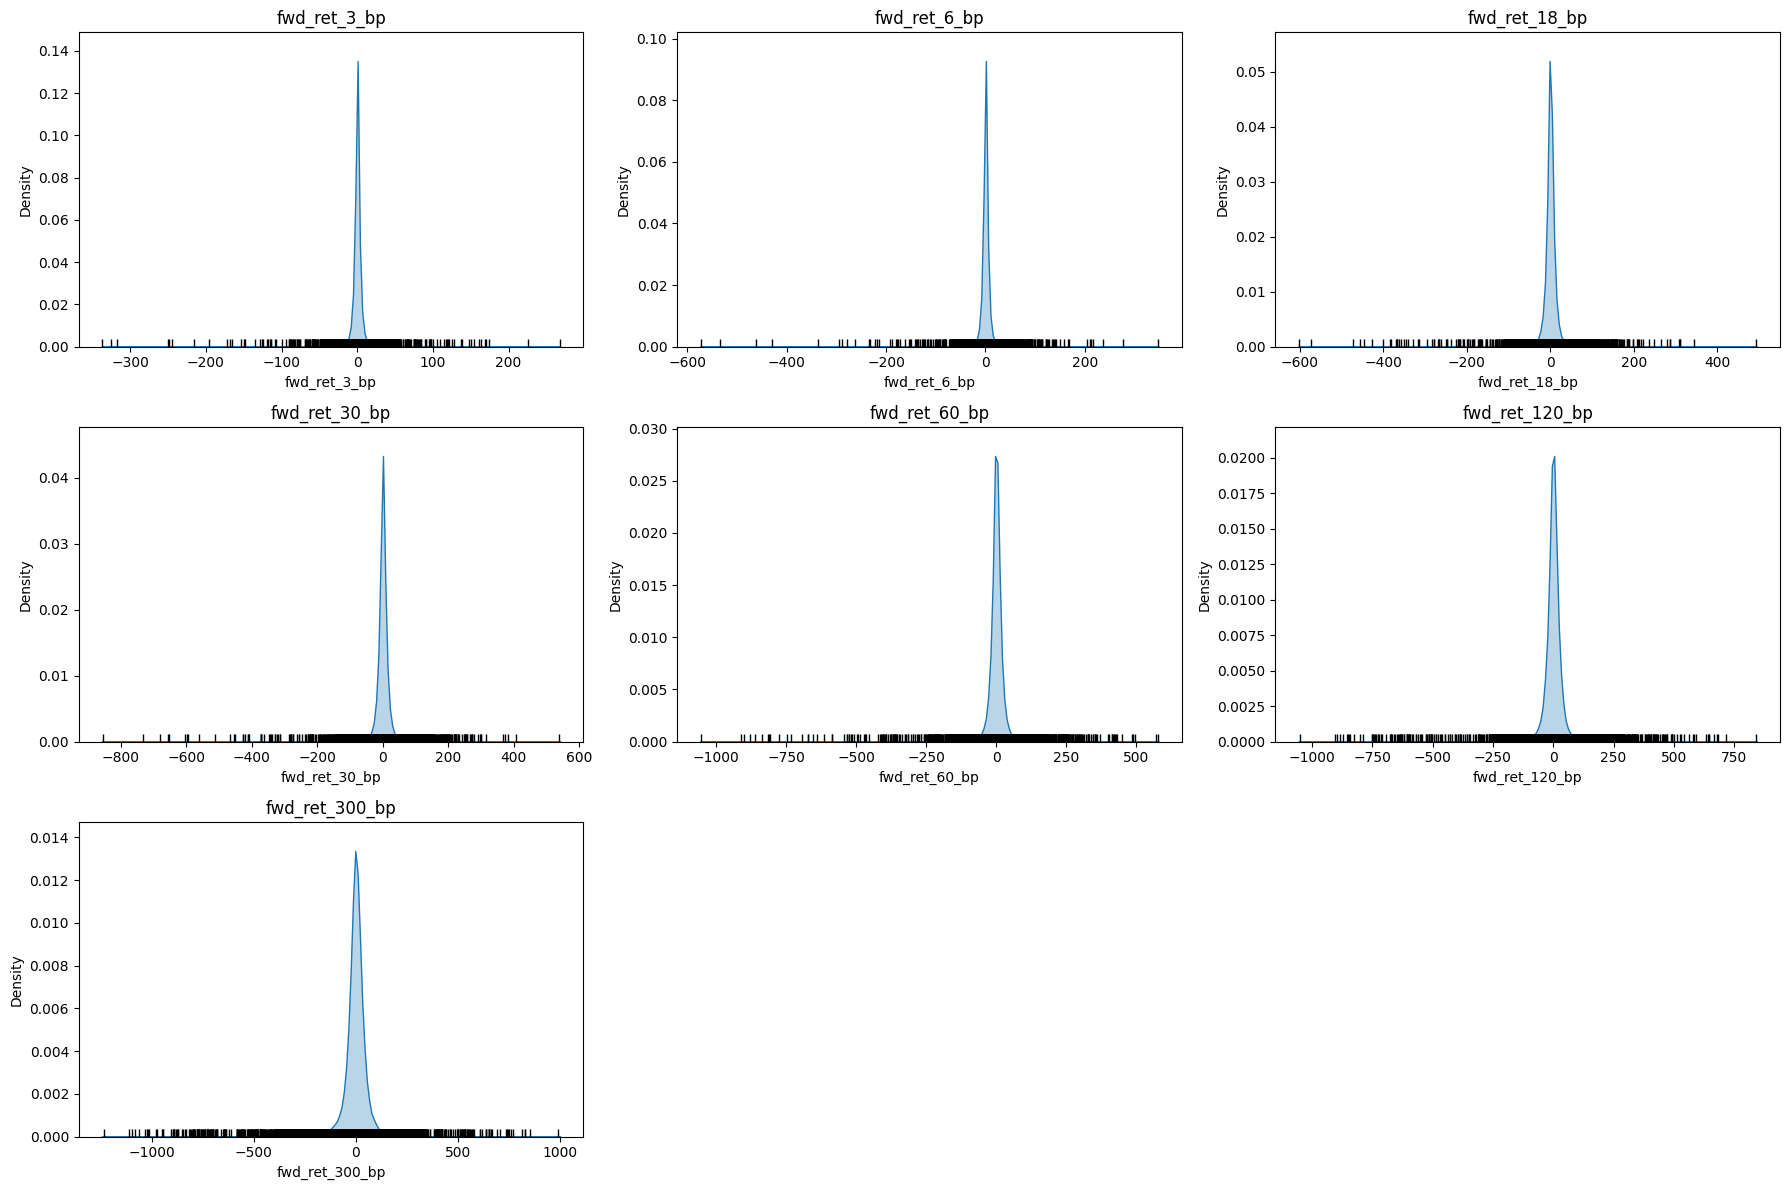

In [66]:
ncols = 3
nrows = int(np.ceil(len(HOLDING_PERIODS) / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6*ncols, 4*nrows))
axes = axes.flatten()

for ax, h in zip(axes, HOLDING_PERIODS):
    col = f'fwd_ret_{h}_bp'
    sns.kdeplot(data=train_df, x=col, fill=True, alpha=0.3, ax=ax)
    sns.rugplot(data=train_df, x=col, color='black', ax=ax)
    ax.set_title(col)

# hide any empty axes
for ax in axes[len(HOLDING_PERIODS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Features 

It is too time consuming to plot each of the 50 features one by one so we will try to separate the features into uncorrelated "blocks" via a dendrogram, and then do EDA on a subset of representative features. 

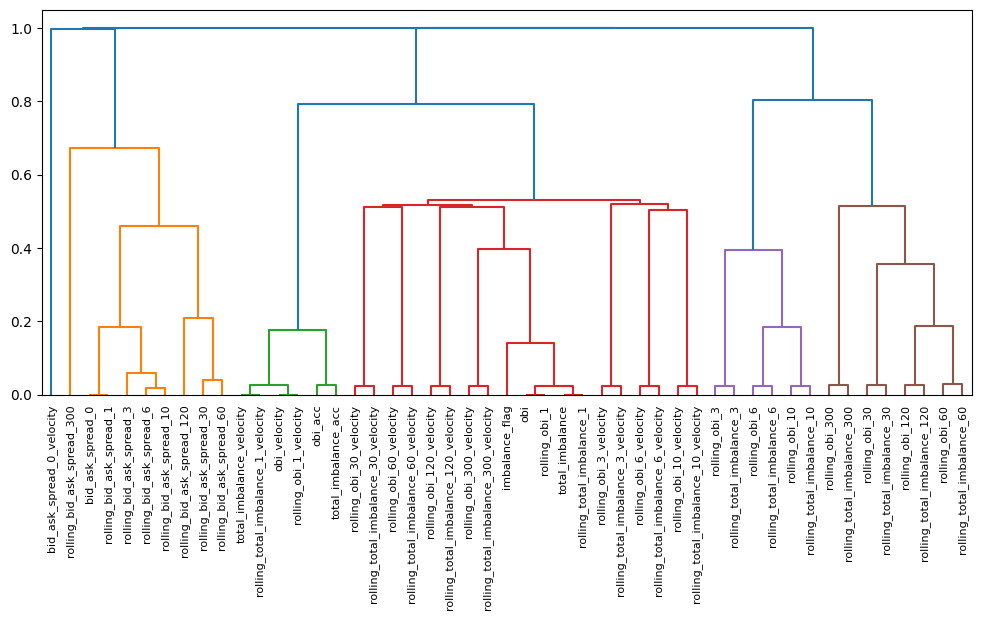

In [143]:
## Interfeature correlation - how to visualise? This is how we can prioritise what features to drill down on/analysefrom scipy.cluster.hierarchy import linkage, dendrogram
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.figure(figsize = (12,5))
dissimilarity = 1 - abs(train_df[FEAS_LIST].corr())
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, labels=train_df[FEAS_LIST].columns, orientation='top', leaf_rotation=90);

We have visualised the correlation clustered as a dendrogram. The main takeaway is that there is very quite a strong correlation between total (instantantaneous) order book imbalance and top level order book imbalance. The representative features we can do EDA are: 
1. bid/ask spread velocity 
2. Rolling bid ask spread measures - just choose maybe 3 (short, medium, long)
3. order book imbalance - velocity/acceleration 
4. rolling imbalance - velocity/acceleration (short, medium long)

Text(0.5, 0.98, 'Correlation between total imbalance (y-axis) and top level imbalance (x-axis)')

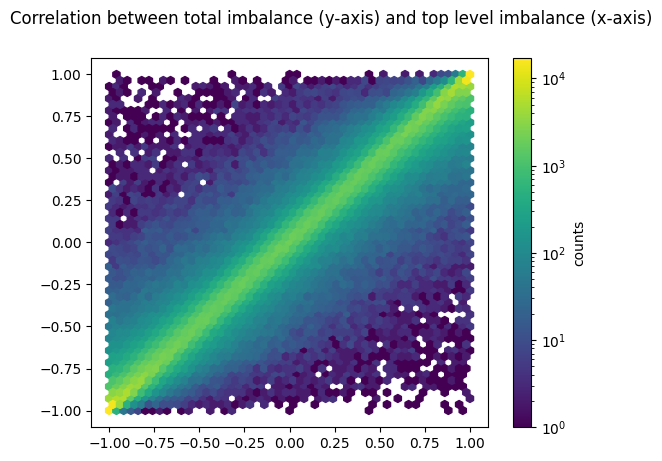

In [8]:
fig, ax = plt.subplots()
hb = ax.hexbin(train_df['obi'], train_df['total_imbalance'], gridsize=50, bins = 'log')
cb = fig.colorbar(hb, ax=ax, label='counts')
fig.suptitle('Correlation between total imbalance (y-axis) and top level imbalance (x-axis)')

## Representative Features 

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


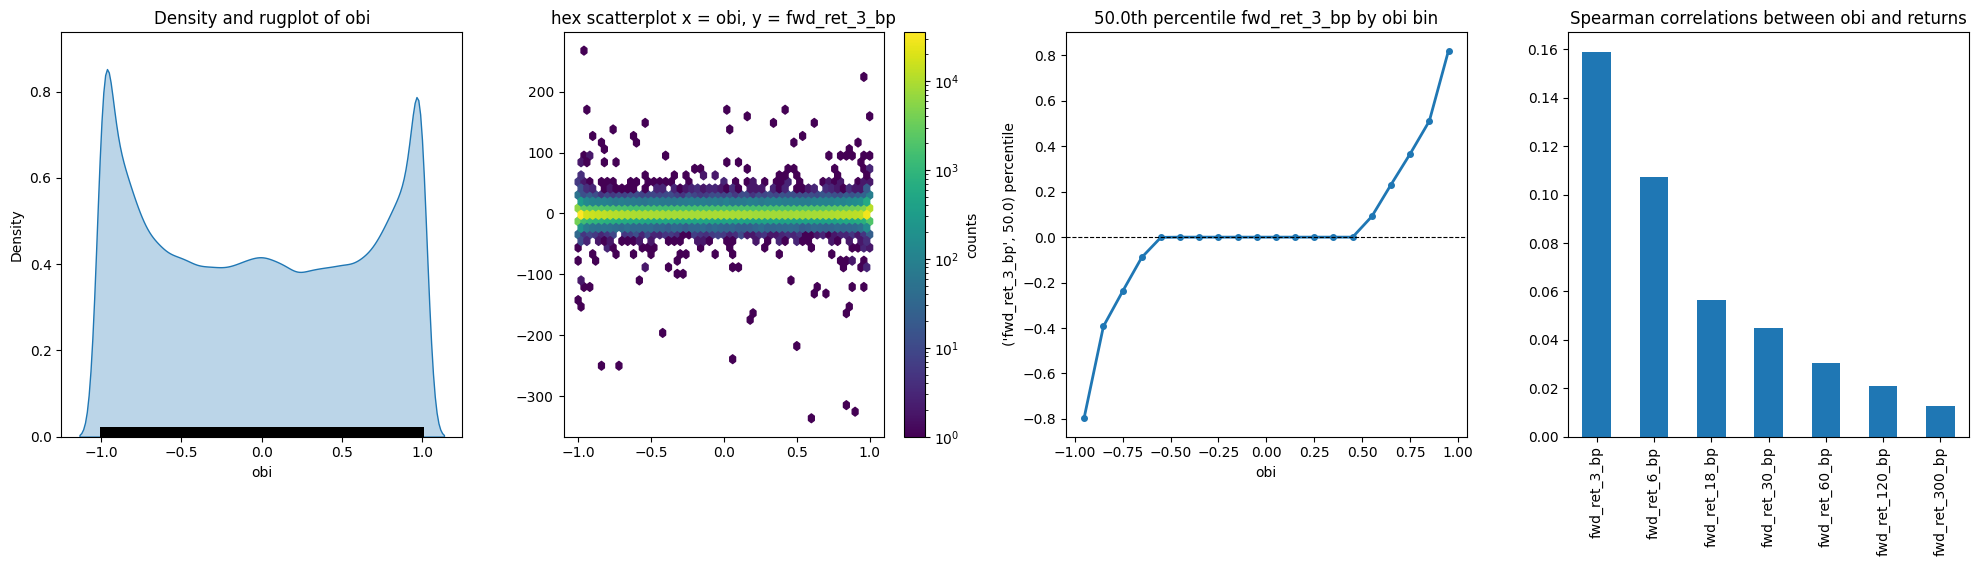

In [5]:
from eda import plot_feature
plot_feature(train_df, 'obi', 'fwd_ret_3_bp')

Correlation between obi and fwd returns is strongest for shortest term horizons. 

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


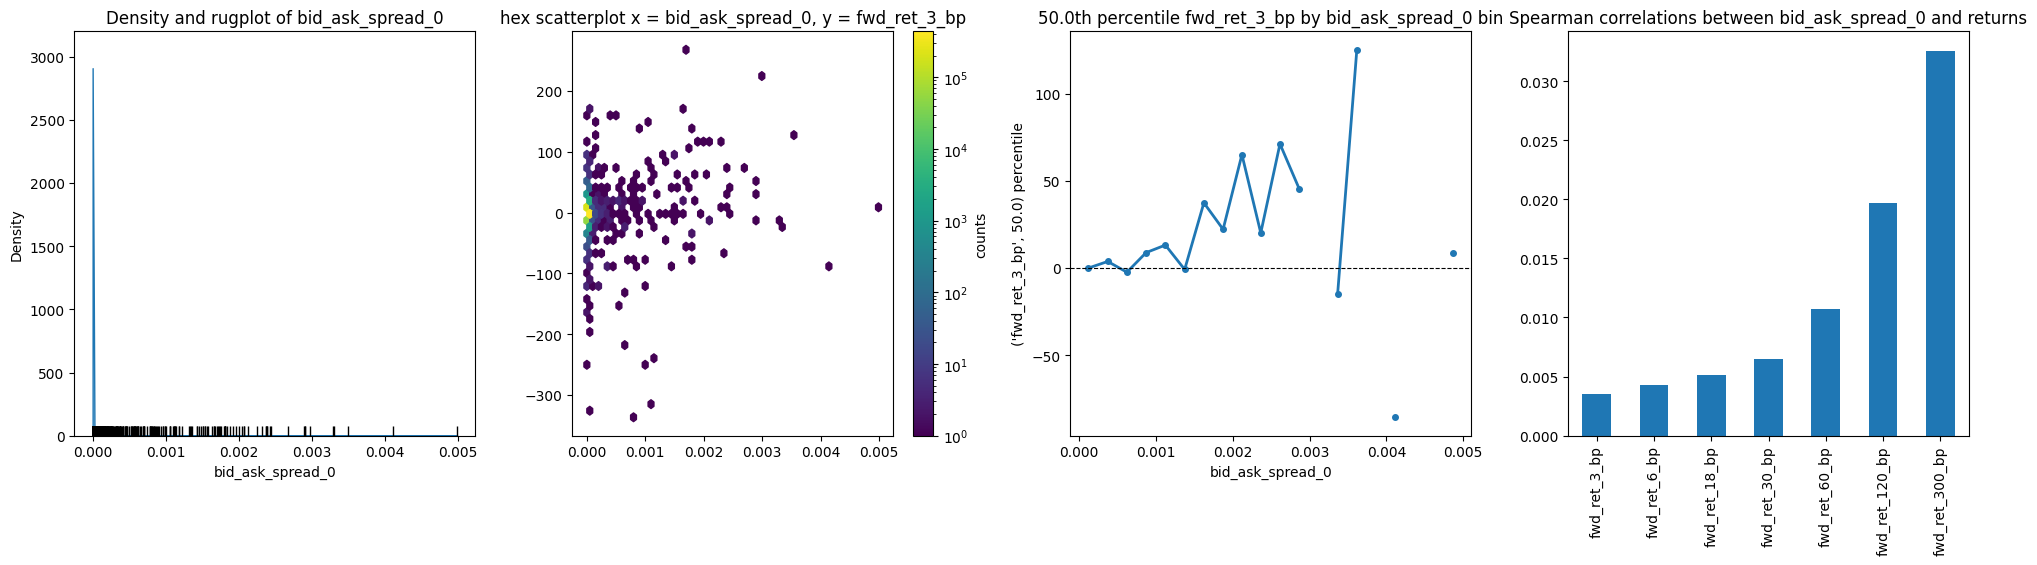

In [6]:
### Bid Ask Spread 
plot_feature(train_df, 'bid_ask_spread_0', 'fwd_ret_3_bp', figsize = (20, 5))

Unclear whether bid/ask spread has a clear/identifiable univariate relationship with short term forward returns. It is interesting that there is an upward trend in relationship with forward returns (as horizon increases). 

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


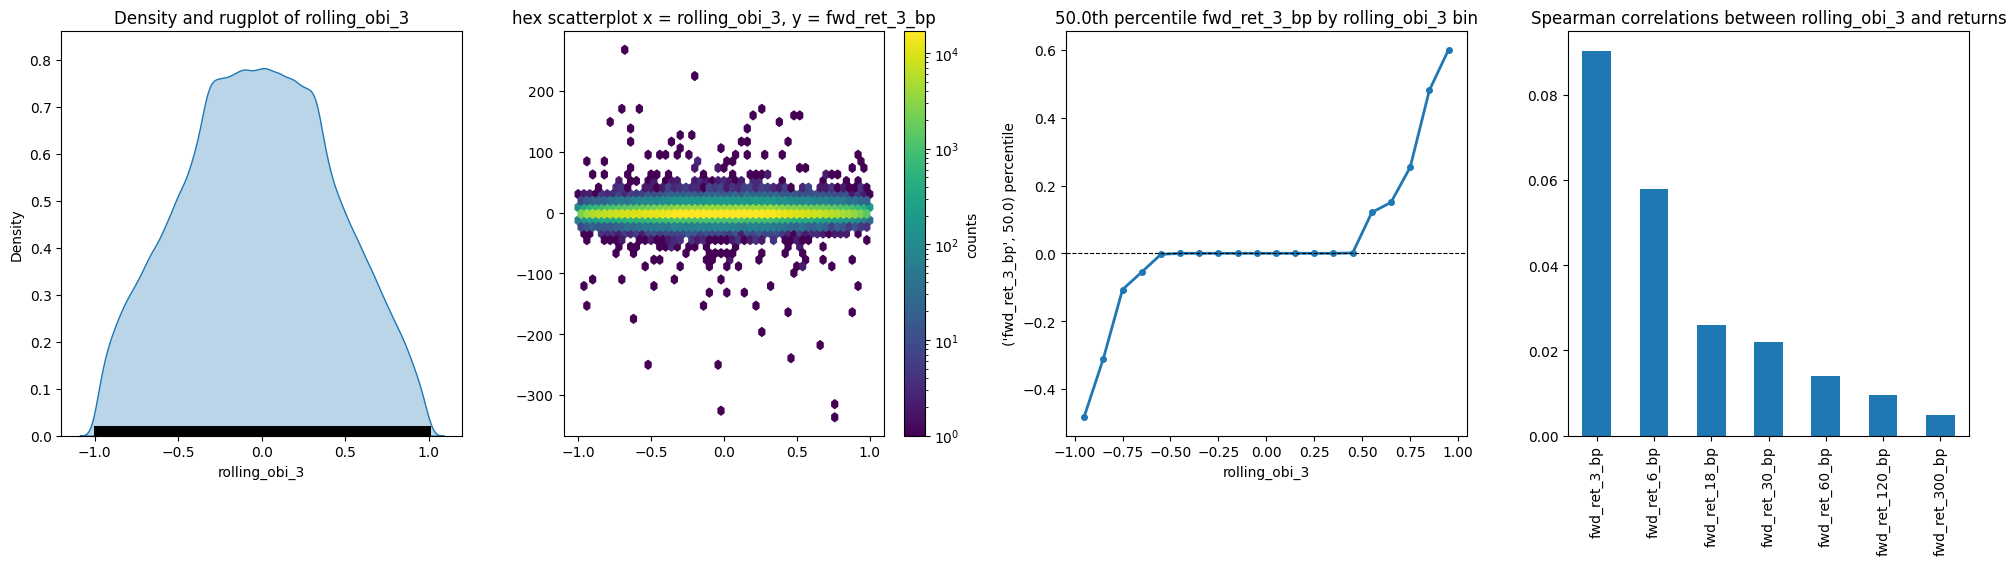

In [12]:
### Rolling OBI - short, medium, long term 
plot_feature(train_df, 'rolling_obi_3', 'fwd_ret_3_bp', figsize = (20, 5))

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


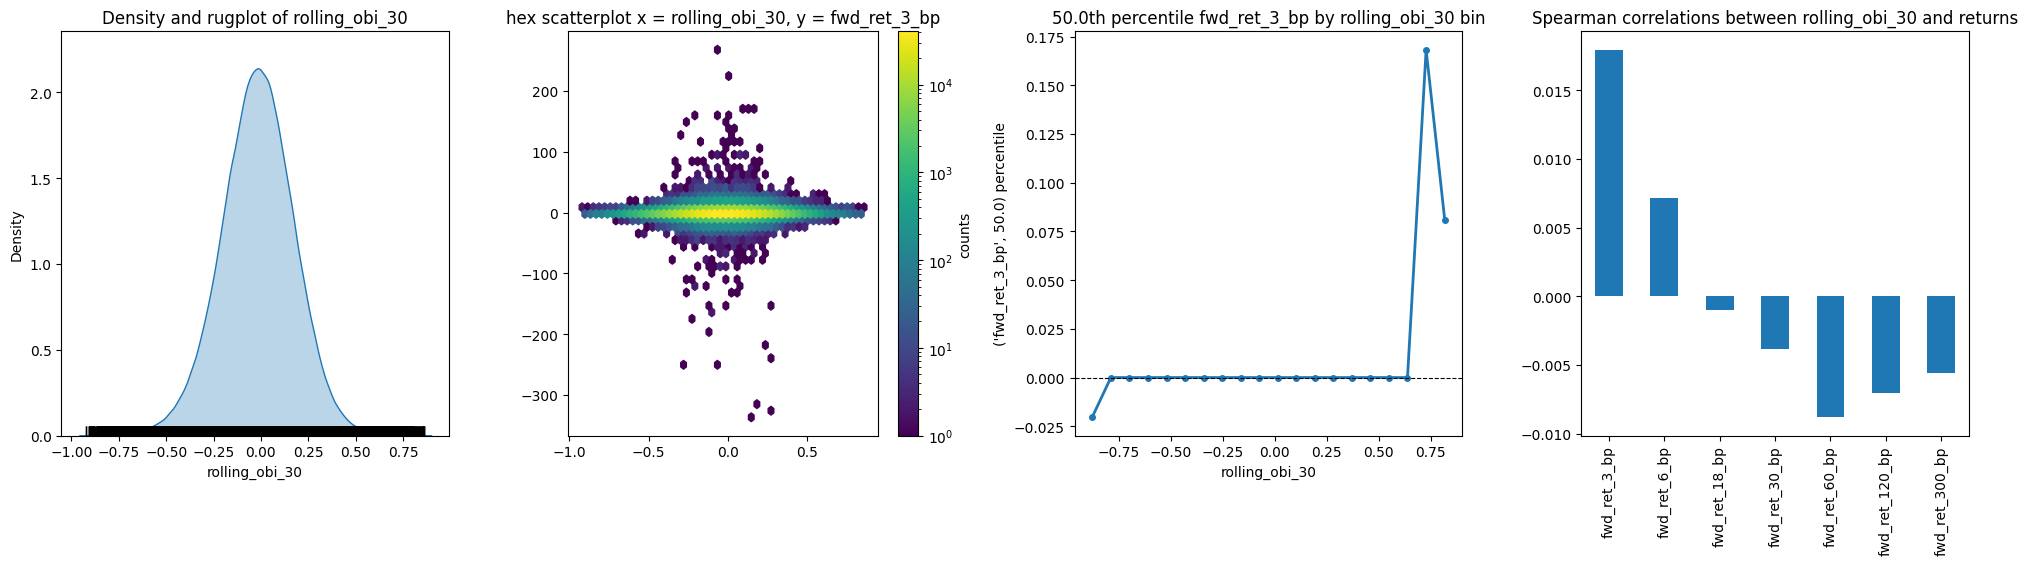

In [13]:
### Velocity 
plot_feature(train_df, 'rolling_obi_30', 'fwd_ret_3_bp', figsize = (20, 5))

/Users/vivbear/Documents/Quant_Research/Projects/momentum_strategies /eda.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = data.groupby('bin')[y].quantile(q = quantile)


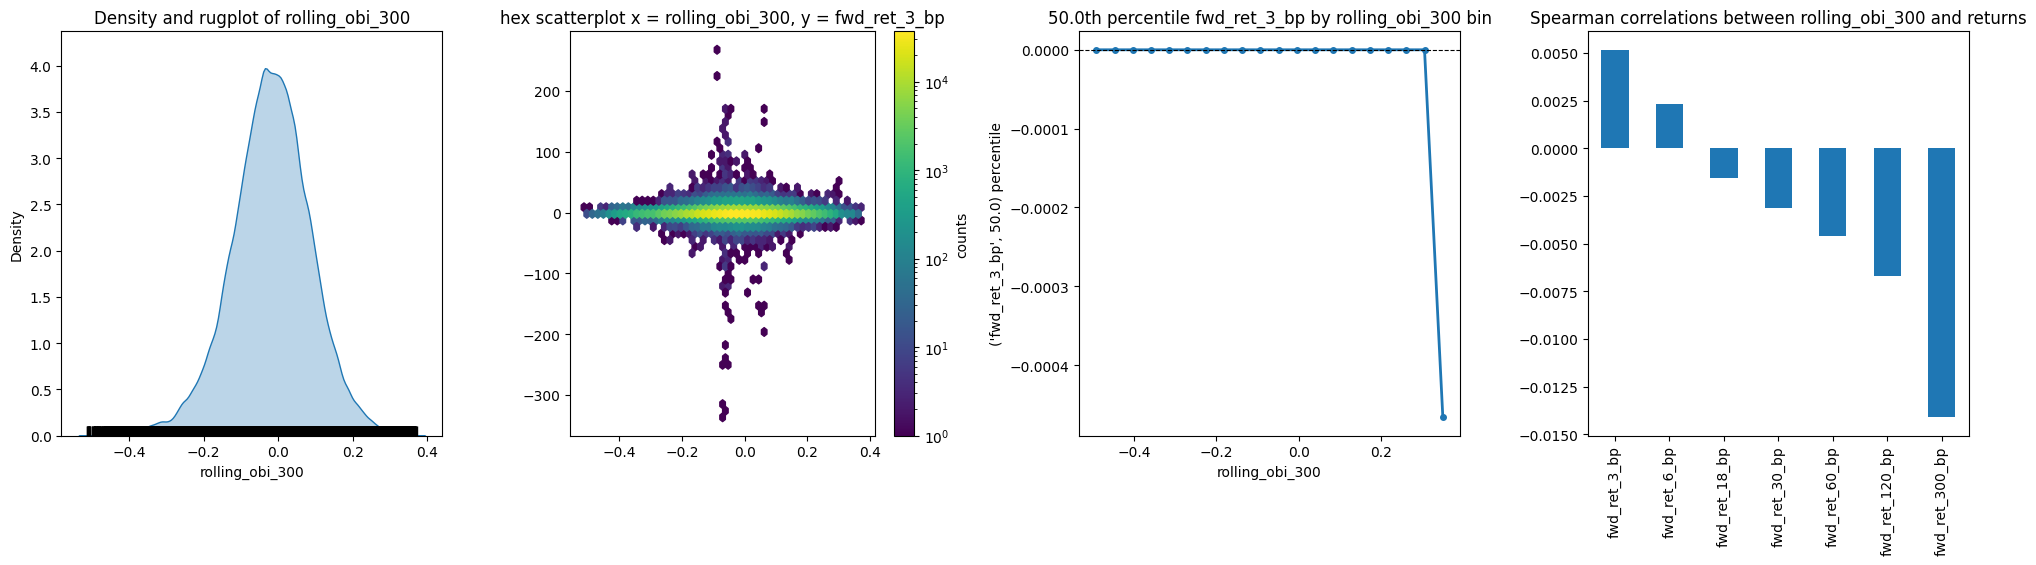

In [14]:
plot_feature(train_df, 'rolling_obi_300', 'fwd_ret_3_bp', figsize = (20, 5))

# Modelling Problem - Returns are symmetric about 0, with the bulk near zero

**Initial Methodology**

My initial attempt at modelling short term future price movements as a function of order flow information was to compare three models: a baseline model (which always predicts 0), a linear quantile regression model and a decision tree model (with appropriately tuned hyperparameters). 

The objective is to minimise MAE - in other words, predict the median price movement of BTC in the next 30 seconds. The decision to minimise MAE is again inspired by the Optiver Kaggle competition mentioned at the start of the notebook. 

To compare model performance I split the training data into k=10 **consecutive, non-overlapping folds**. In each fold, we retrain the data on the first 80% and then validate performance on the remaining 20%. The decision to have more frequent retraining is due to the fact that the correlation between instantaneous OBI and future 30 second returns appears to evolve over time. 

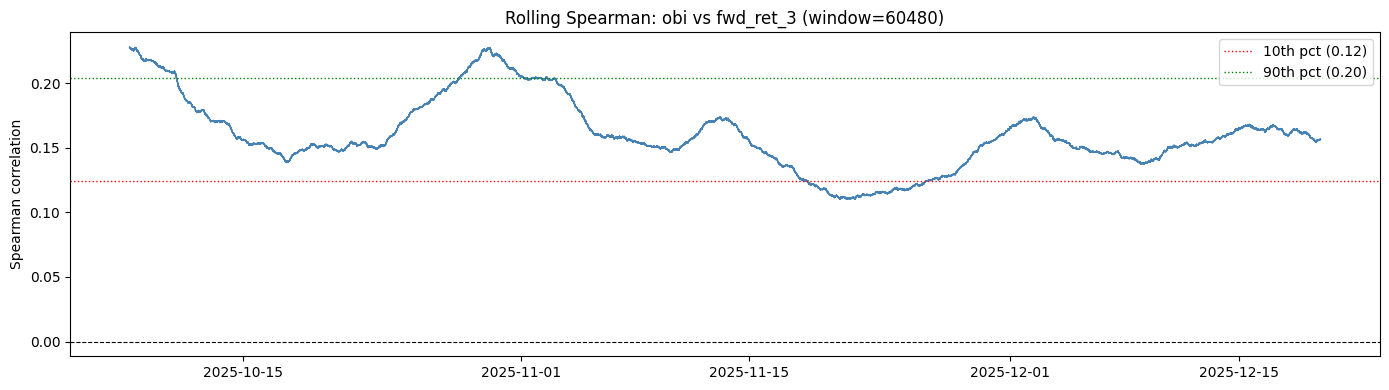

In [9]:
#Plot - rolling correlation 

window = 168*360 #number of 10 second ticks in one week 
from data_visualisation import plot_rolling_spearman
plot_rolling_spearman(train_df, 'obi', 'fwd_ret_3', window = window)

## Performance Analysis

We evaluated performance of quantile regression, decision trees and baseline model performance across the 10 folds. 

After tuning hyperparameters to account for overfitting, a more detailed visual analysis of our modelling performance shows: 
1. Instability across folds 
2. Inability for model to learn from training data - our trained models really don't differ much from the benchline 0 model! 

This is the same regardless of whether we fit a complex model to many order flow features (e.g. decision model to all 50 features) and try to account for overfitting by toggling hyperparameters, or whether we fit a simple model to just one feature (e.g. quantile regression with just the order flow imbalance). 

I have only shown the results from training a (tuned) decision tree model but the results are basically identical for a linear quantile regression model. 

In [10]:
from train import walk_forward_validate

In [17]:
params= {
    #General params 
    'device': 'cpu', 
    'enable_categorical': True,
    #Tree params
    'booster': 'gbtree',
    #Learning Task Params 
    'objective': 'reg:absoluteerror', 
    'max_depth': 3,
    'learning_rate': 0.05, #decrease the learning rate 
    'n_estimators': 100,
    'subsample': 0.75,
    'early_stopping_rounds': 20,
    'n_estimators': 200,
}
results = walk_forward_validate(train_df, features = FEAS_LIST, model_kwargs=params, target = TARGET, cv_kwargs = {'num_splits': 10})

  0%|          | 0/10 [00:00<?, ?it/s]

In [19]:
baseline_model = walk_forward_validate(train_df, features = FEAS_LIST, target = TARGET, cv_kwargs= TRAIN_TEST_SPLIT_PARAMS, model_type = 'baseline')

  0%|          | 0/10 [00:00<?, ?it/s]

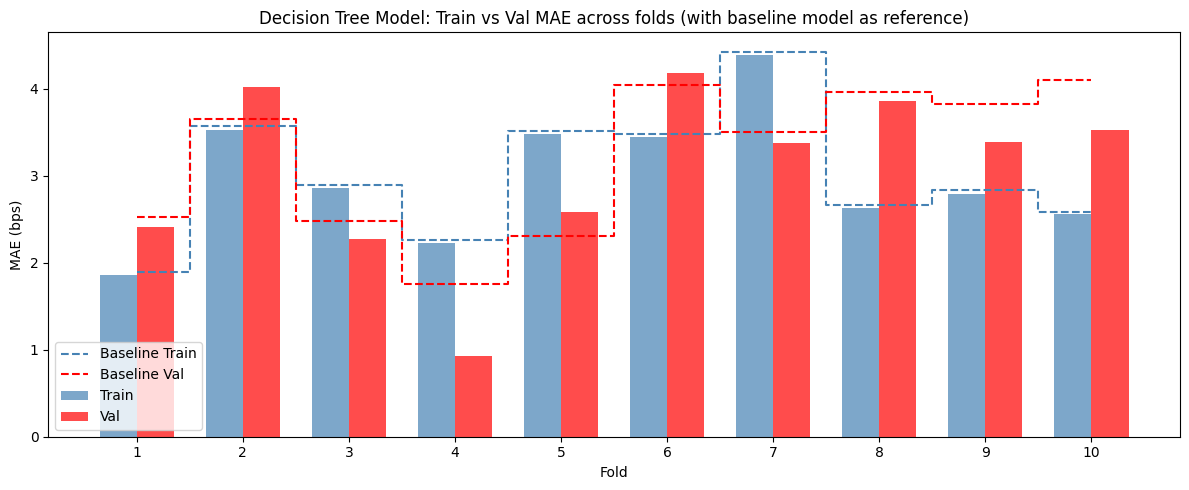

In [23]:
InteractiveShell.ast_node_interactivity = "last_expr"
fig, ax = plt.subplots(figsize=(12, 5))
folds = np.arange(1, len(results['val_scores']) + 1)
width = 0.35

ax.bar(folds - width/2, results['train_scores'], width=width, label='Train', alpha=0.7, color='steelblue')
ax.bar(folds + width/2, results['val_scores'], width=width, label='Val', alpha=0.7, color='red')

ax.step(folds, baseline_model['train_scores'], where='mid',color='steelblue', lw=1.5, ls='--', label='Baseline Train')
ax.step(folds, baseline_model['val_scores'], where='mid',color='red', lw=1.5, ls='--', label='Baseline Val')

ax.set_xlabel('Fold')
ax.set_ylabel('MAE (bps)')
ax.set_title('Decision Tree Model: Train vs Val MAE across folds (with baseline model as reference)')
ax.set_xticks(folds)
ax.legend()
plt.tight_layout()
plt.show()

Thus, even though from just comparing training mean vs validation mean it seems like we can beat the baseline, this is inaccurate. In each fold, notice that we are failing to learn almost anything in the sense that are our predictions are super close to 0. 

## Problem - Returns are too fat tailed 

Ultimately the problem is that the return distribution is WAY too peaked - there are lots of extreme values but the majority is concentrated around 0. This means that any kind of model "trained" on training data is basically indistinguishable from a dummy model that predicts 0 every time. This problem is also responsible for why it would appear that our "trained" model does better sometimes on validation folds than on training folds! 

It just so happens that our crude way of splitting up the folds sometimes induces differing distributions on the returns. If a validation fold **happens* to have short-term returns that are bunched up around 0, this gives the illusion that our trained model performs "better" on validation data. 

For example, the first plot shows the rolling median for fold 3, where it initially seems (from the plot above) that the model performs better on validation data. In fact this is jsut because the returns in the validation period are all close to 0. Contrast with the second plot that shows the rolling median for fold 1 - in this case the distribution of returns is roughly similar between train/validation, which is consistent with the fact that our trained model has a lower CV score in fold 1. 

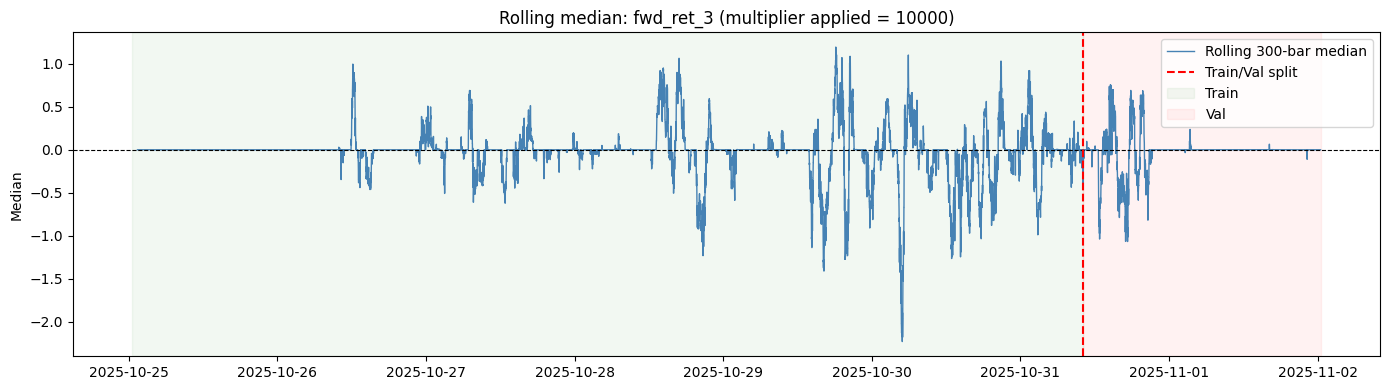

In [24]:
from data_visualisation import plot_rolling_mae
from train import train_test_split 
tss= train_test_split(data_length = len(train_df), num_splits = 10, split_ratio = 0.8)
plot_rolling_mae(train_df, target = 'fwd_ret_3', train_idx = tss[3][0], val_idx = tss[3][1], window = 300, multiplier = BASIS_POINTS_CONVERSION)

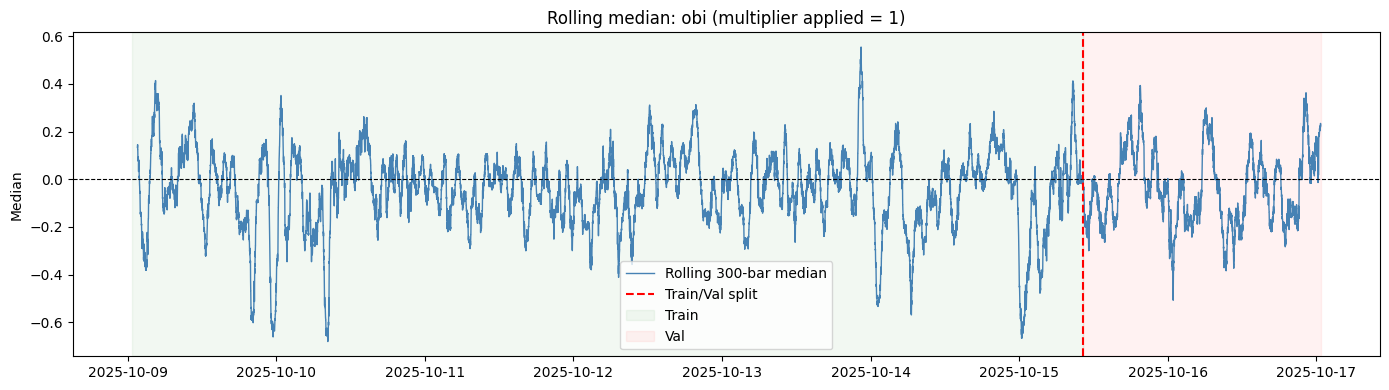

In [25]:
plot_rolling_mae(train_df, target = 'obi', train_idx = tss[1][0], val_idx = tss[1][1], window = 300)

# Attempt 2 - Directly model extreme values 